## 1) 스태킹(Stacking) 앙상블
* 배깅 및 부스팅과의 공통점 : 개별적인 여러 알고리즘을 서로 결합해 예측 결과를 도출함
* 배깅 및 부스팅과의 차이점 : 개별 알고리즘으로 예측한 데이터를 기반으로 다시 예측을 수행
* 핵심
  * 개별 알고리즘의 예측 결과 데이터셋 -> 최종적인 메타 데이터셋으로 만듦 -> 별도의 ML 알고리즘으로 최종 학습 수행 -> 테스트 데이터 기반으로 다시 최종 예측 수행
  * 메타 모델 : 개별 모델의 예측된 데이터셋을 다시 기반으로 해 학습하고 예측하는 방식
  * 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합 -> 최종 메타 모델의 학습용 피처 데이서셋 & 테스트용 피처 데이터셋을 만듦
* 두 종류의 모델이 필요
  * 개별적인 기반 모델
  * 최종 메타 모델 : 개별 기반모델의 예측 데이터를 학습 데이터로 만들어 학습함
* 많은 모델이 필요하며, 주로 성능이 비슷한 모델을 결합해 좀 더 나은 성능 향상을 도출하기 위해 적용함
* 스태킹 앙상블 예시
  * 데이터셋은 M개의 로우, N개의 피처(칼럼) 가짐
  * 학습에 사용할 ML 알고리즘 모델은 3개
  * 원본 데이터로 각각 학습시키고 예측 수행 -> M개 로우 가진 1개의 레이블값 도출 (M X 1 데이터 3개)
  * 모델별로 도출된 예측 레이블 값을 다시 합해(스태킹) 새로운 데이터셋 만듦
  * 스태킹된 데이터셋에 대해 최종 모델 적용 -> 최종 예측함
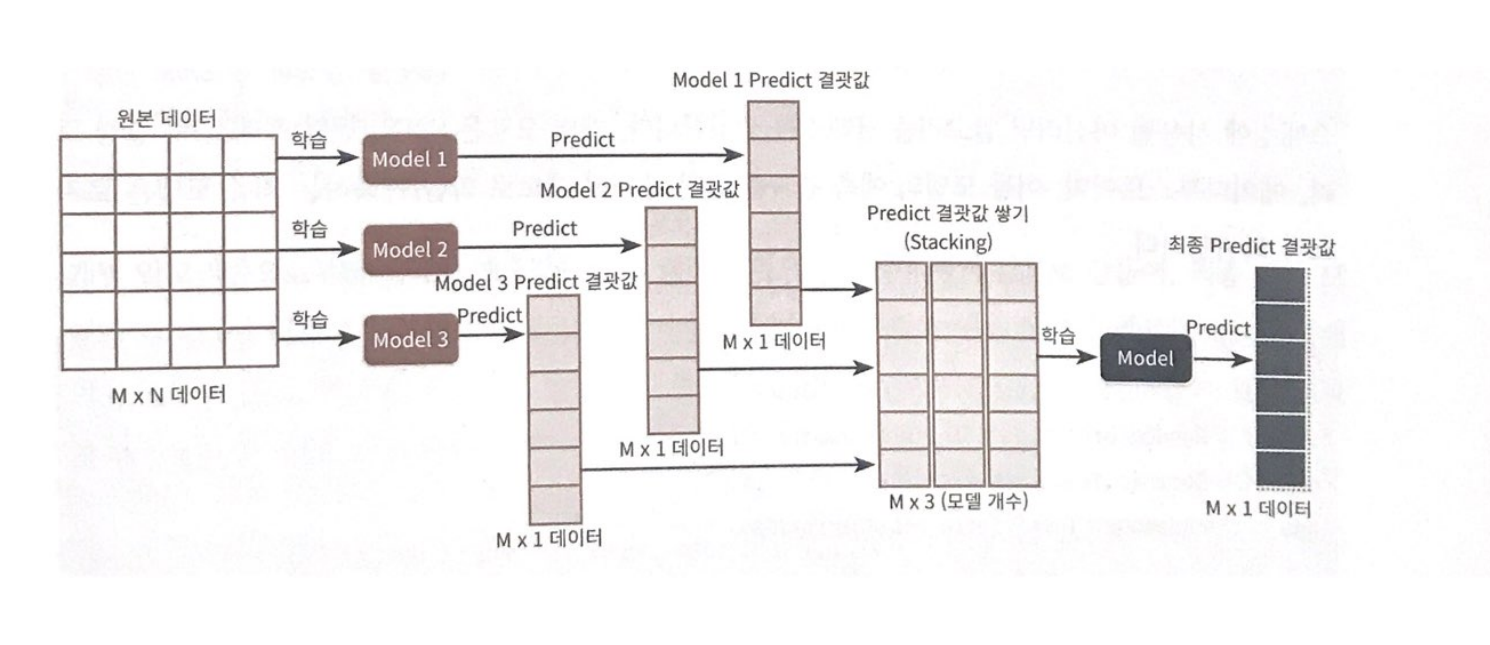

In [10]:
### 라이브러리 임포트
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, mean_absolute_error

## 2) 기본 스태킹 모델

In [7]:
### 데이터 로딩

cancer_data = load_breast_cancer()

x_data = cancer_data.data
y_label = cancer_data.target

x_train, x_test, y_train, y_test = train_test_split(x_data, y_label, test_size=0.2, random_state=0)

In [8]:
### 스태킹에 사용될 머신러닝 알고리즘 클래스 생성
#개별 ML 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

#스태킹으로 만들어진 데이터셋을 학습, 예측할 최종 모델
lr_final = LogisticRegression(C=10)

#개별 모델 학습
knn_clf.fit(x_train, y_train)
rf_clf.fit(x_train, y_train)
dt_clf.fit(x_train, y_train)
ada_clf.fit(x_train, y_train)

#개별 모델들이 각자 반환하는 예측 데이터셋 생성
knn_pred = knn_clf.predict(x_test)
rf_pred = rf_clf.predict(x_test)
dt_pred = dt_clf.predict(x_test)
ada_pred = ada_clf.predict(x_test)

# 개별 모델들의 정확도 측정
print('KNN 정확도 : {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도 : {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정트리 정확도 : {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('AdaBoost 정확도 : {0:.4f}'.format(accuracy_score(y_test, ada_pred)))


KNN 정확도 : 0.9211
랜덤 포레스트 정확도 : 0.9649
결정트리 정확도 : 0.9123
AdaBoost 정확도 : 0.9561


In [9]:
#개별 알고리즘으로부터 예측된 예측값을 칼럼 레벨로 옆으로 붙여 피처 값으로 만듦
pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred]) #반환된 예측 데이터셋은 1차원 형태 -> 일단 행 형태로 붙임
print(pred.shape)
pred = np.transpose(pred) #칼럼 레벨로 각 알고리즘의 예측 결과를 피처로 만듦
print(pred.shape)

#최종 메타모델인 로지스틱 회귀에서 학습 데이터로 다시 사용
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)
print('최종 메타 모델의 예측 정확도 : {0:.4f}'.format(accuracy_score(y_test, final)))

(4, 114)
(114, 4)
최종 메타 모델의 예측 정확도 : 0.9737


## 3) CV 세트 기반의 스태킹
* 과적합을 개선하기 위함 -> 최종 메타 모델을 위한 데이터셋 만들 때 교차 검증 기반으로 예측된 결과 데이터셋 이용
  * 앞 2)절에서 로지스틱 회귀 최종 메타 모델에 레이블 데이터셋으로 학습 데이터가 아닌 테스트용 레이블 데이터셋으로 학습해서 과적합 문제 발생 가능
* 개별 모델들이 각각 교차 검증으로 메타 모델을 위한 학습용 스태킹 데이터 생성 & 예측 위한 테스트용 스태킹 데이터 생성 -> 이를 기반으로 메타 모델이 학습과 예측 수행
* 순서
  1. 각 모델 별로 원본 학습/테스트 데이터 예측한 결과값 기반으로 -> 메타 모델을 위한 학습/테스트용 데이터 생성
    * 개별 모델에서 메타 모델(2차 모델_에 학습될 학습용테스트용 데이터를 교차검증을 통해 생성함이 요점
    * 개별 모델 레벨에서 수행하는 단계임
    * 이런 로직을 어려 개의 개별 모델에서 동일하게 수행
  2. 개별 모델 생성 학습용 데이터를 모두 스태킹 형태로 합쳐 메타 모델이 학습할 최종 학습용 데이터셋 생성. 테스트용도 마찬가지
  3. 메타 모델은 최종 생성된 학습 데이터셋 & 원본 학습 데이터의 레이블 데이터 기반으로 학습 -> 최종적으로 생성된 테스트 데이터셋 예측 -> 원본 테스트 데이터의 레이블 데이터 기반으로 평가
* 순서 1번 상세 : 학습용 데이터를 N개의 폴드로 나눔 - N번의 유사한 반복 작업 수행 -> 마지막 반복에서 개별 모델의 예측값으로 학습/테스트 데이터 생성
  1. 학습용 데이터를 N개의 폴드로 나누되, N-1개의 폴드는 학습을 위한 데이터 폴드, 남은 하나 폴드는 검증을 위한 데이터 폴드. N-1개로 나뉜 학습 데이터를 기반으로 개별 모델을 학습
  2. 학습된 개별 모델을 검증 폴드 1개 데이터로 예측하고 그 결과 저장 -> 이를 N번 반복하며 학습/검증 데이터셋 변경해가며 학습 후 예측 결과 별도 저장 -> 나중에 메타 모델을 학습시키는 학습 데이터로 사용됨
  3. N-1개의 학습 폴드 데이터로 학습된 개별 모델은, 원본 테스트 데이터를 에측해 예측값 생성 -> 이를 N번 반복하며, 이 예측값의 평균으로 최종 결괏값 생성 -> 메타 모델을 위한 테스트 데이터로 사용됨
  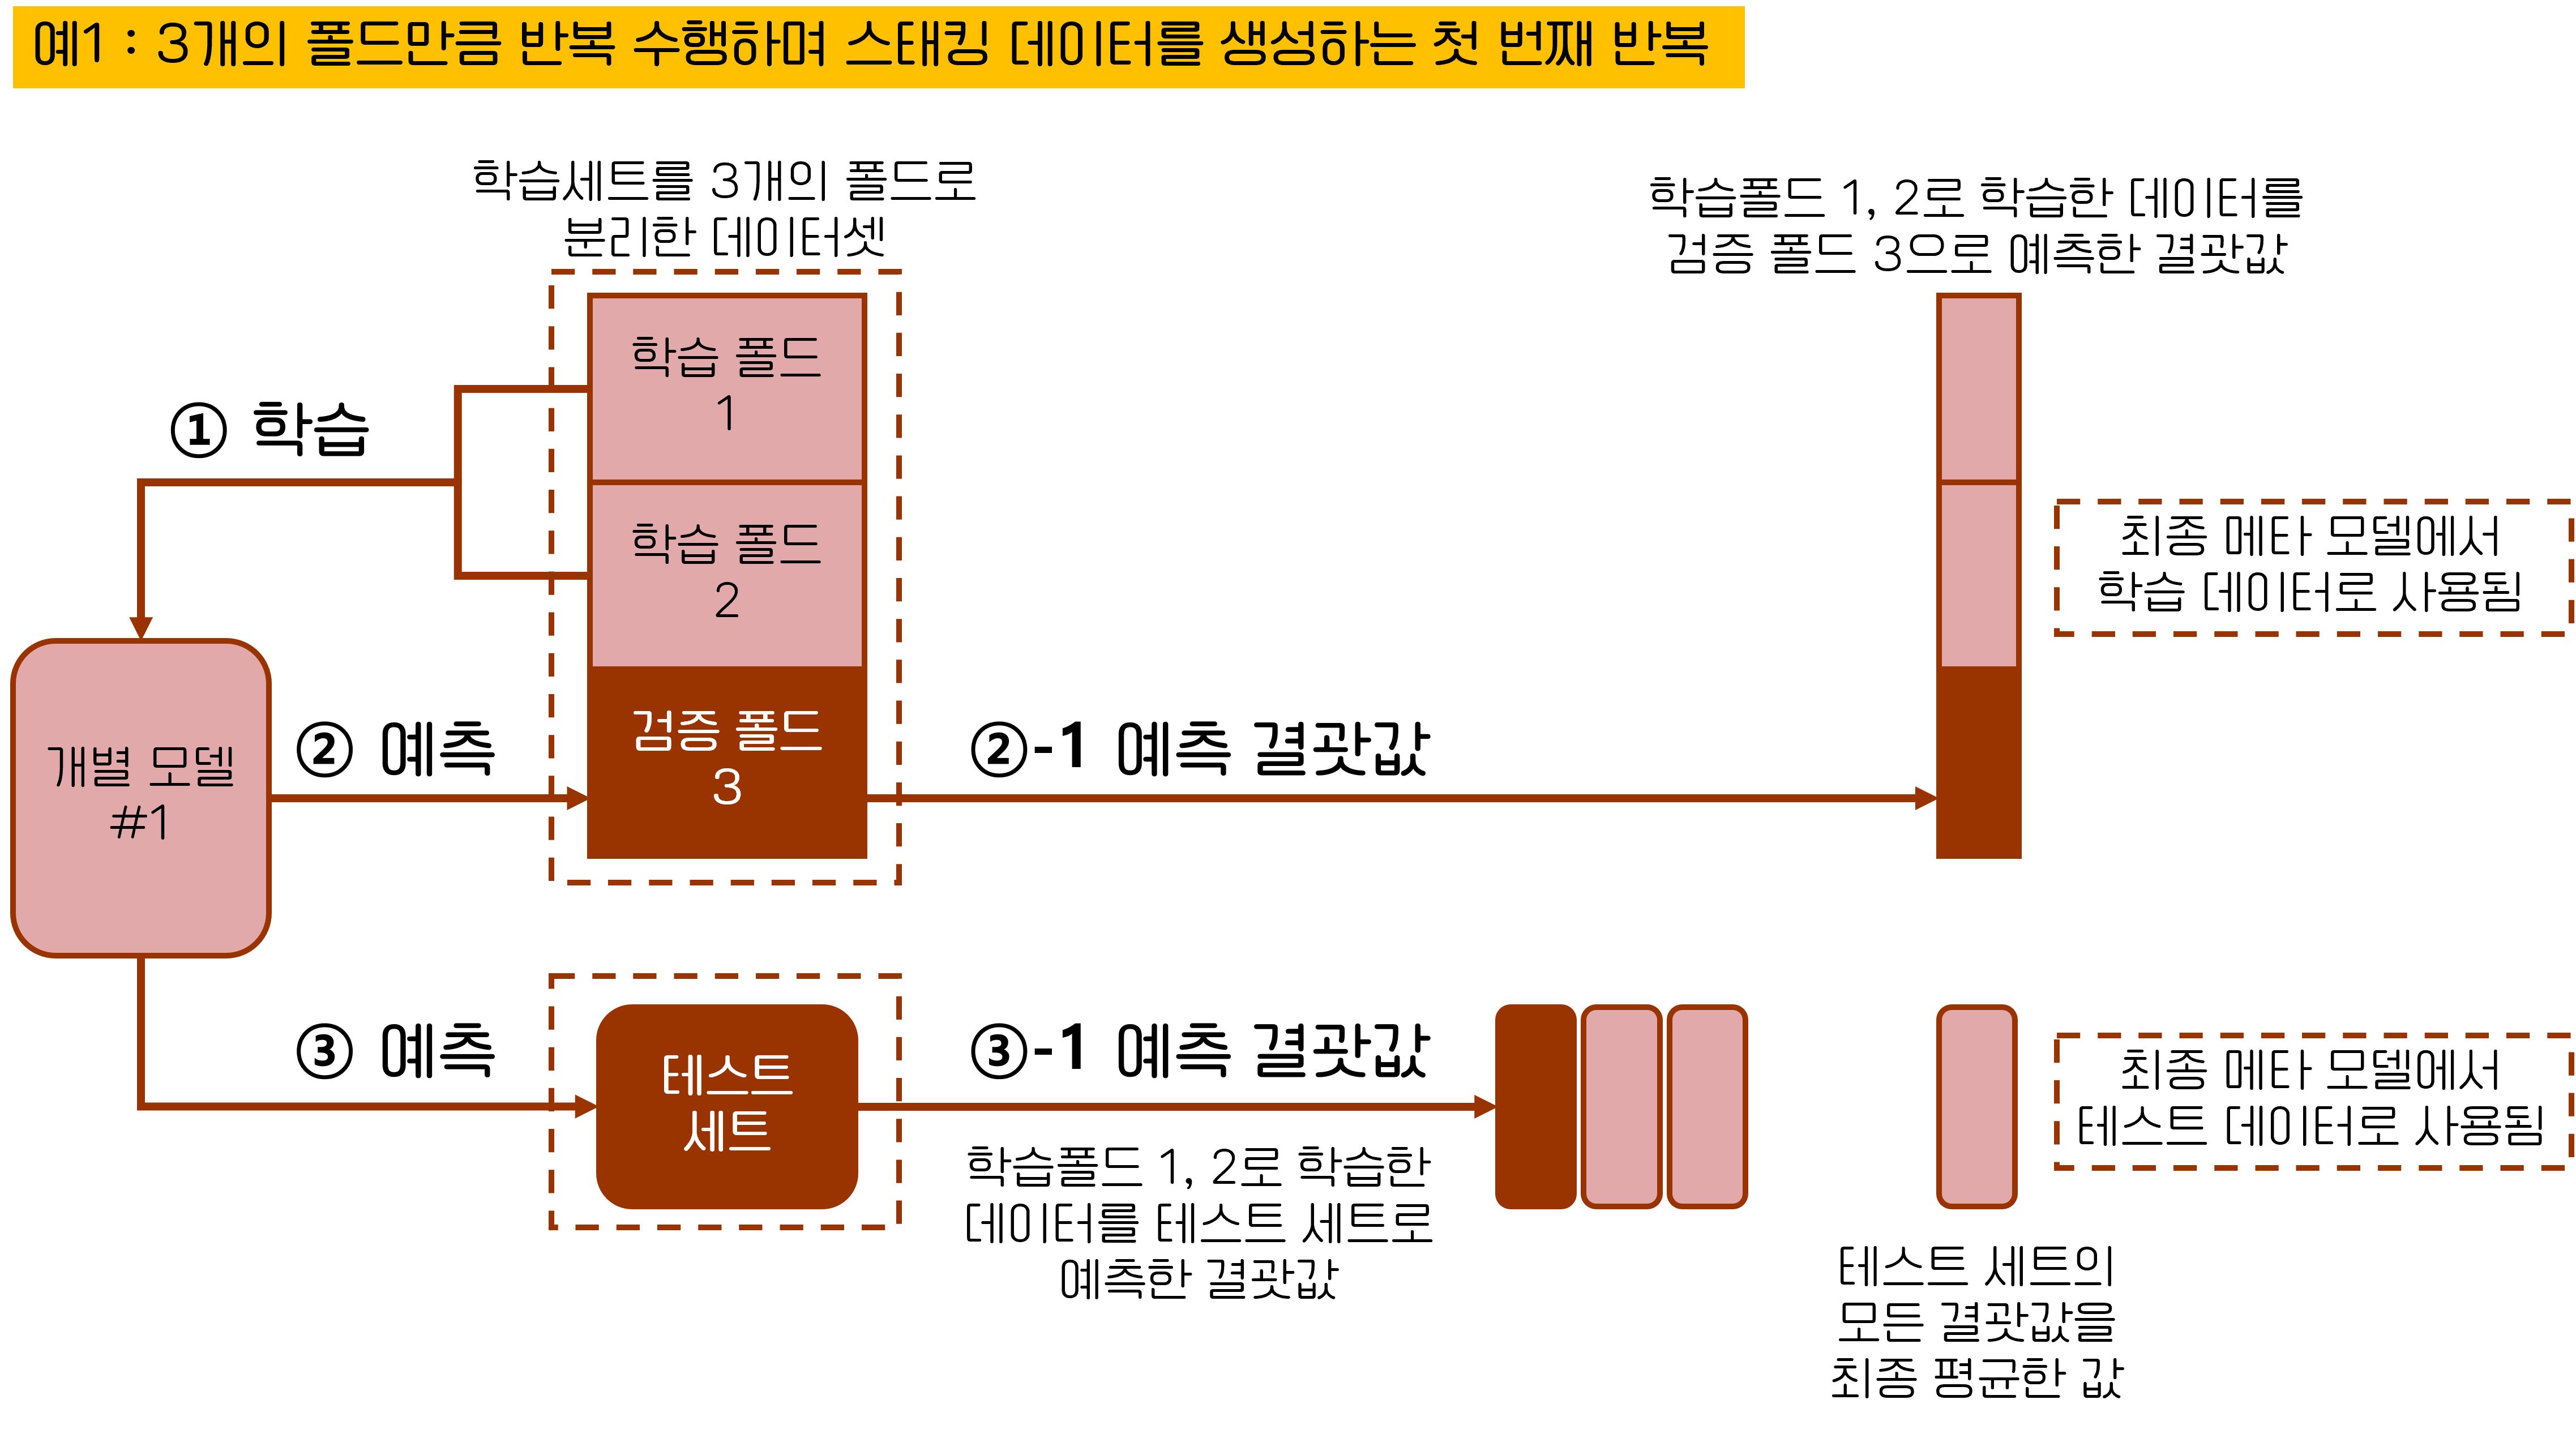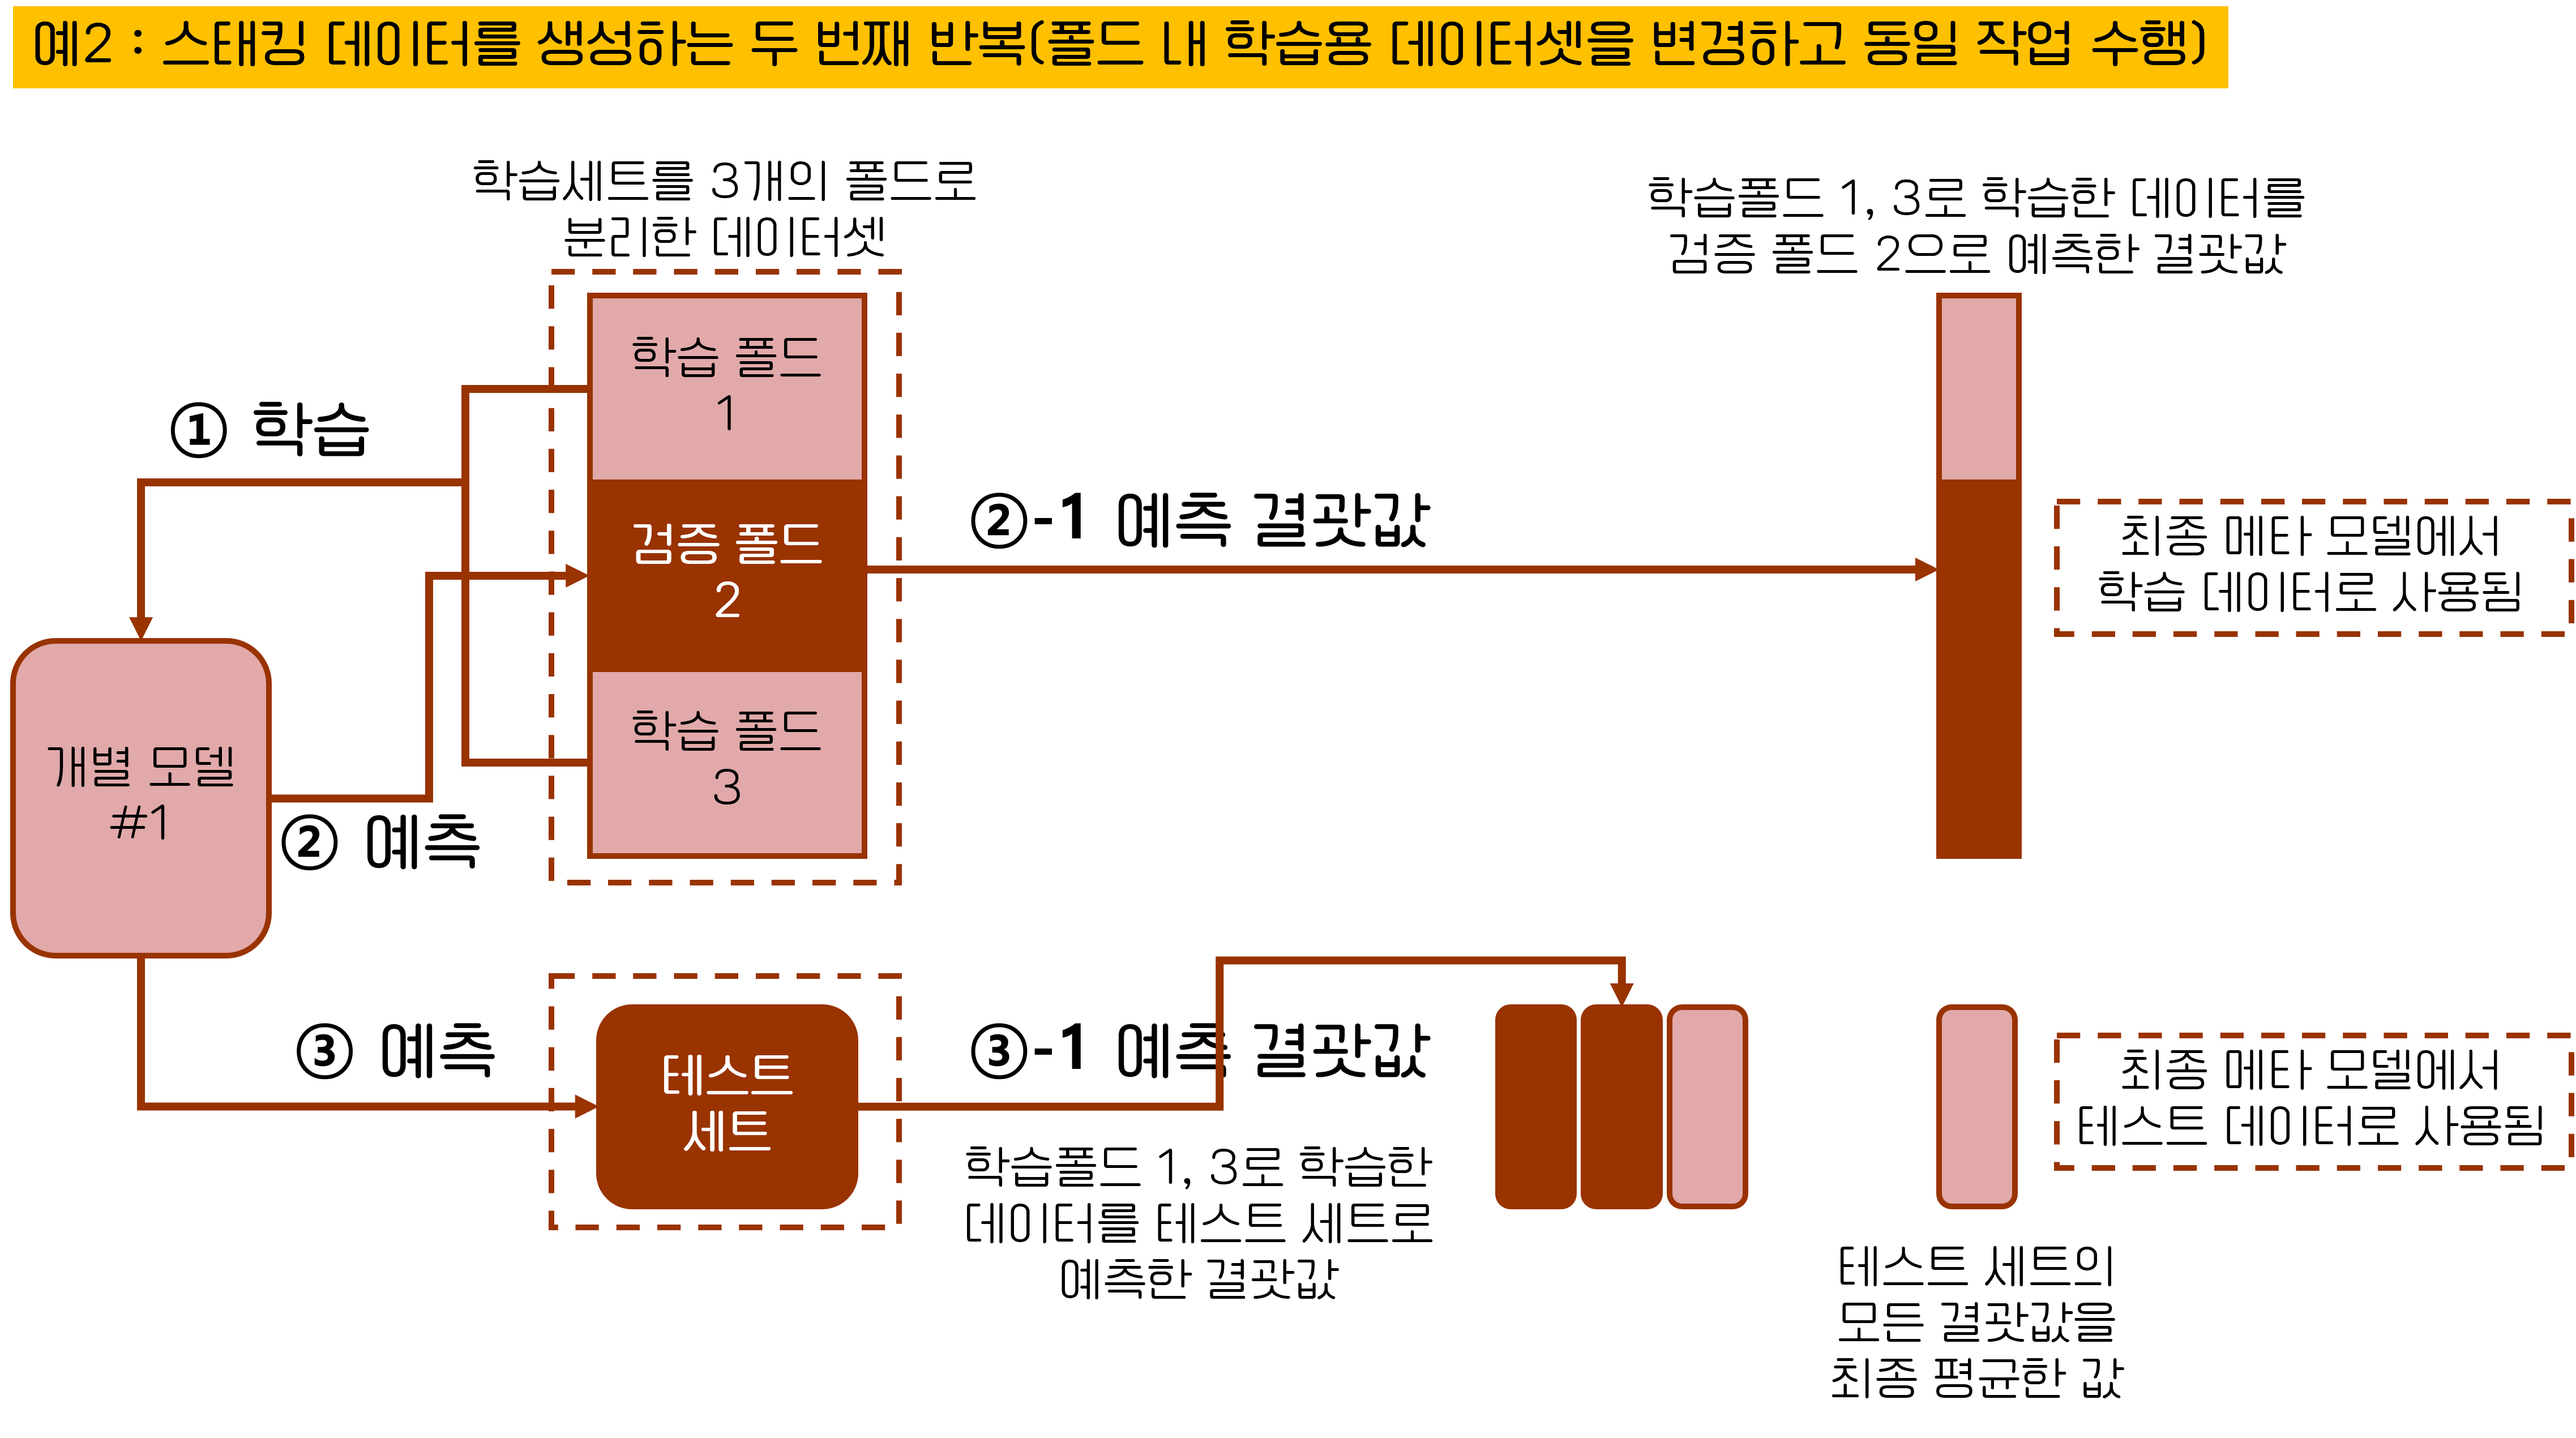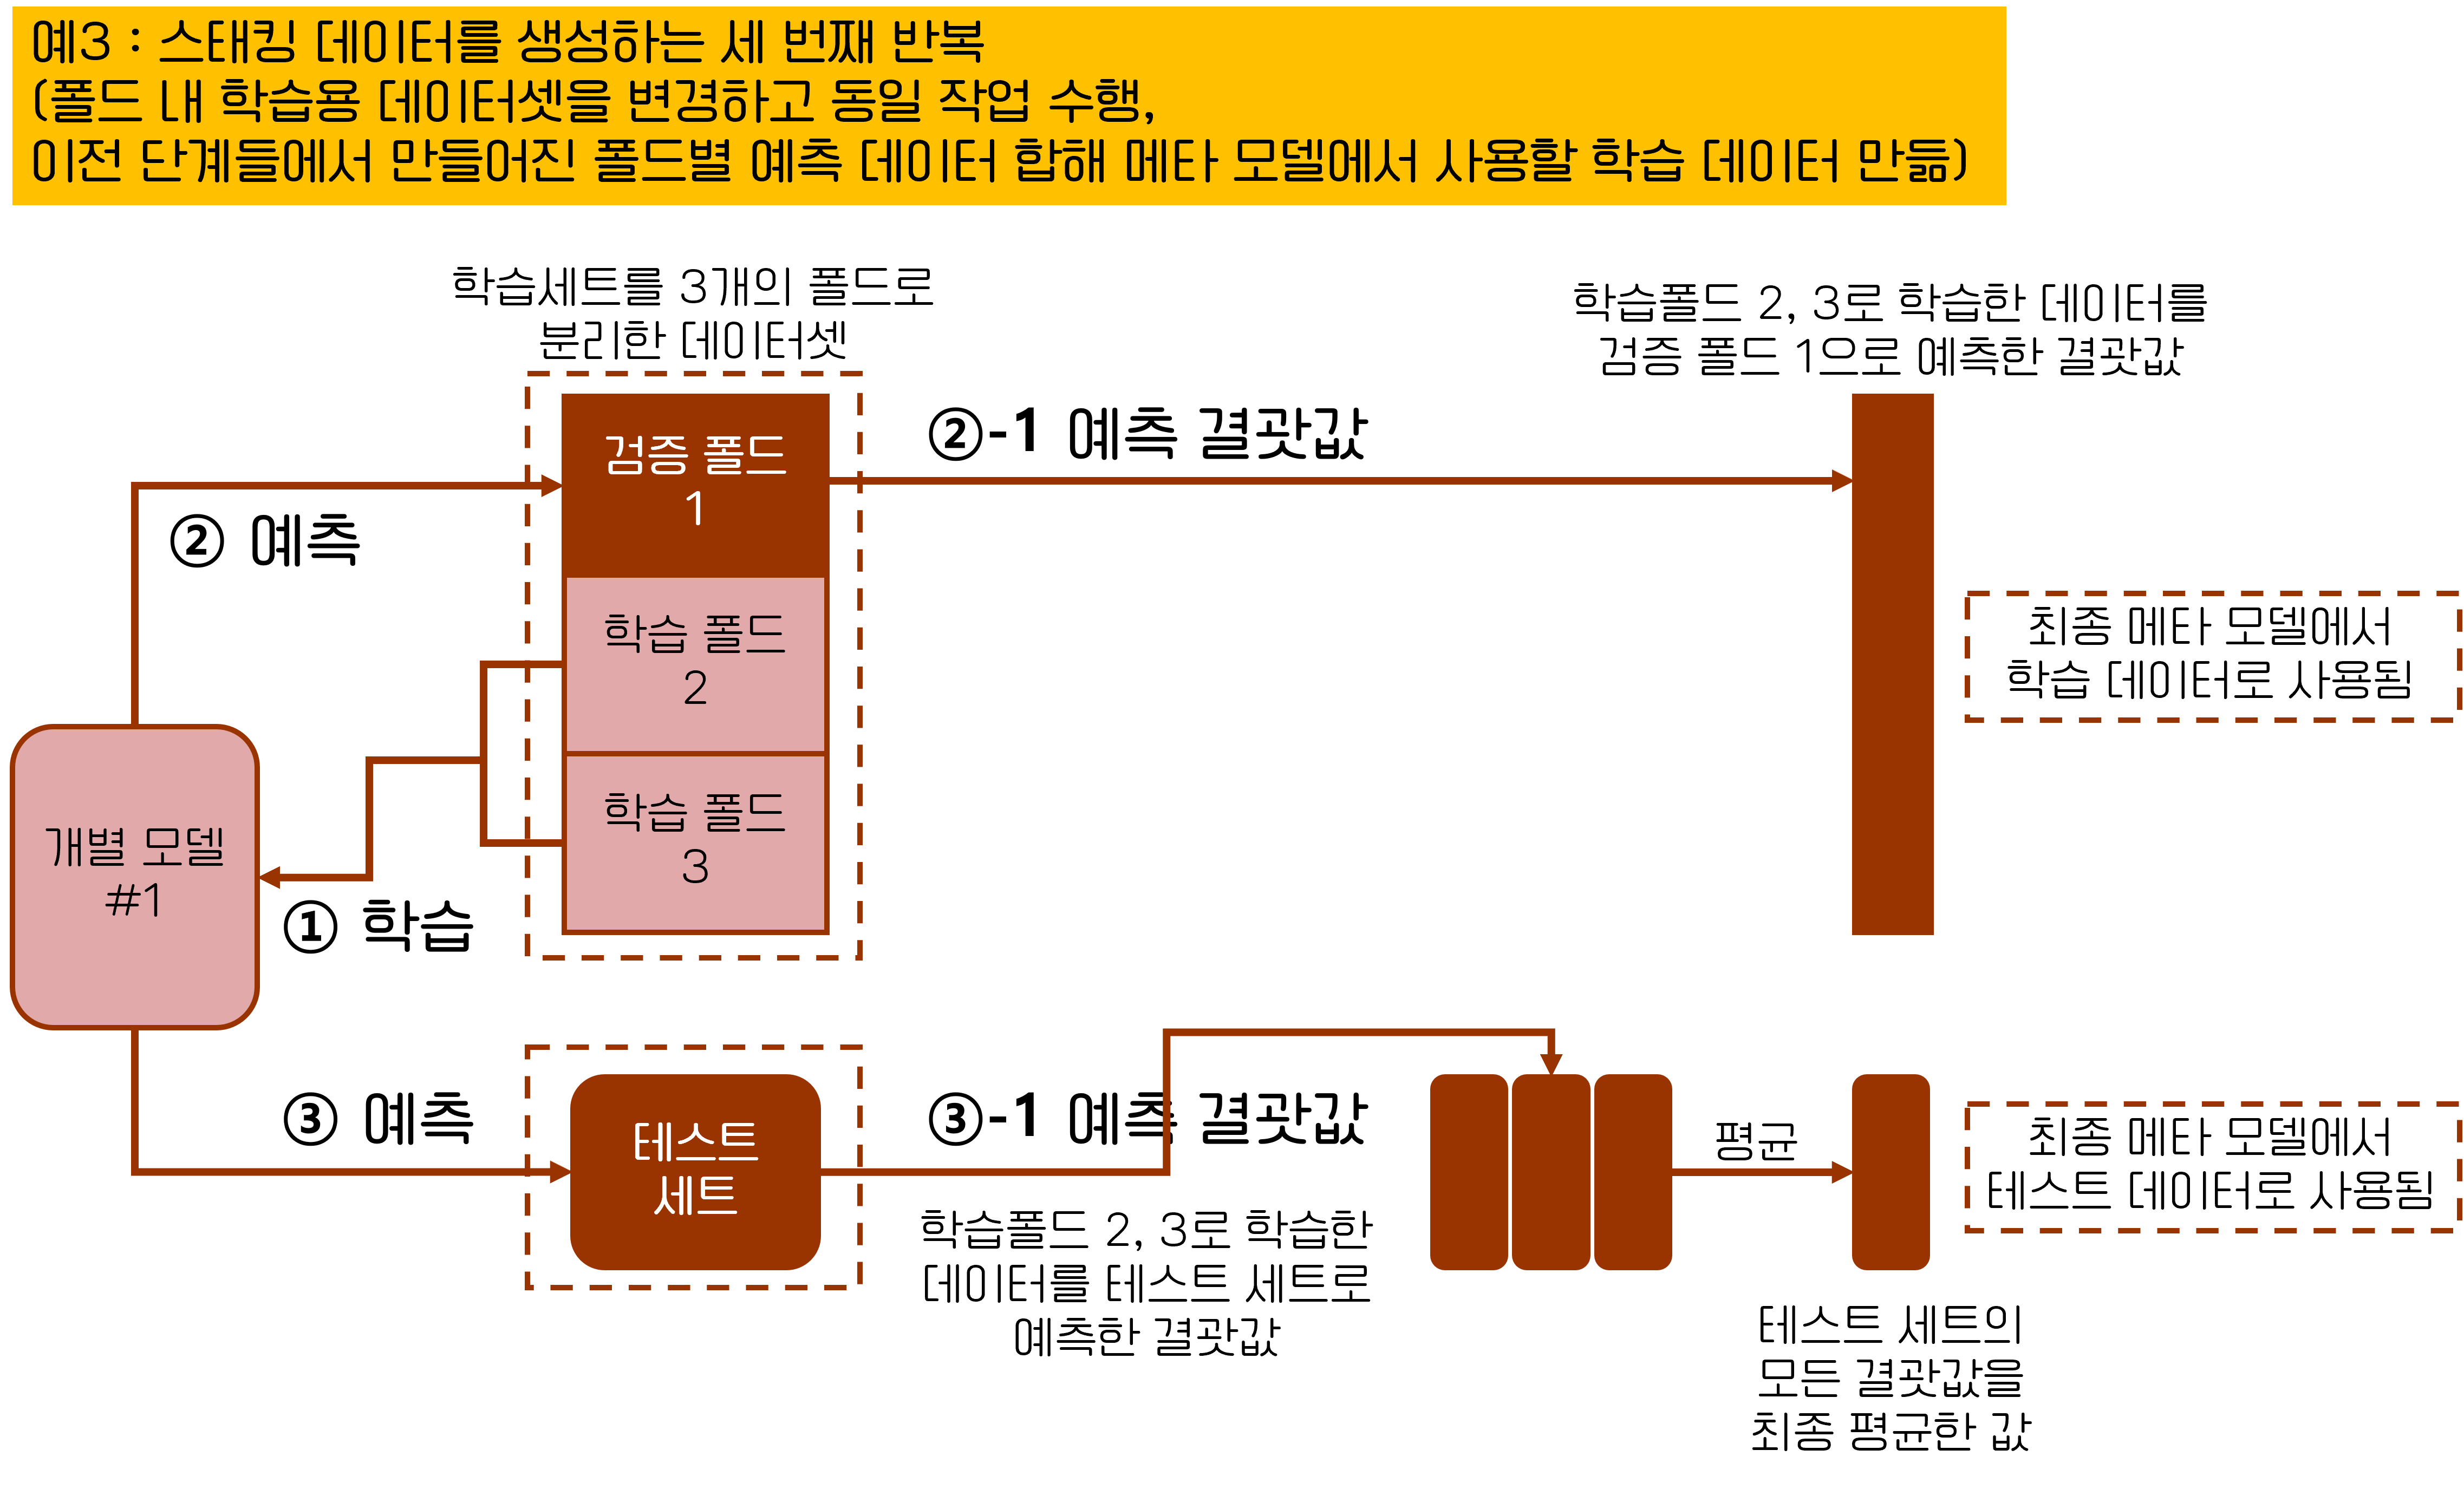
* 순서 2번 상세
  * 각 모델들이 이전 순서에서 생성한 학습/테스트 데이터 모두 합쳐 -> 최종적으로 메타 모델이 사용할 학습/테스트 데이터 생성
* 순서 3번 상세
  * 메타 모델 학습, 최종 데트스 데이터로 예측 수행, 최종 예측 결과를 원본 테스트 데이터의 레이블 데이터와 비교해 평가
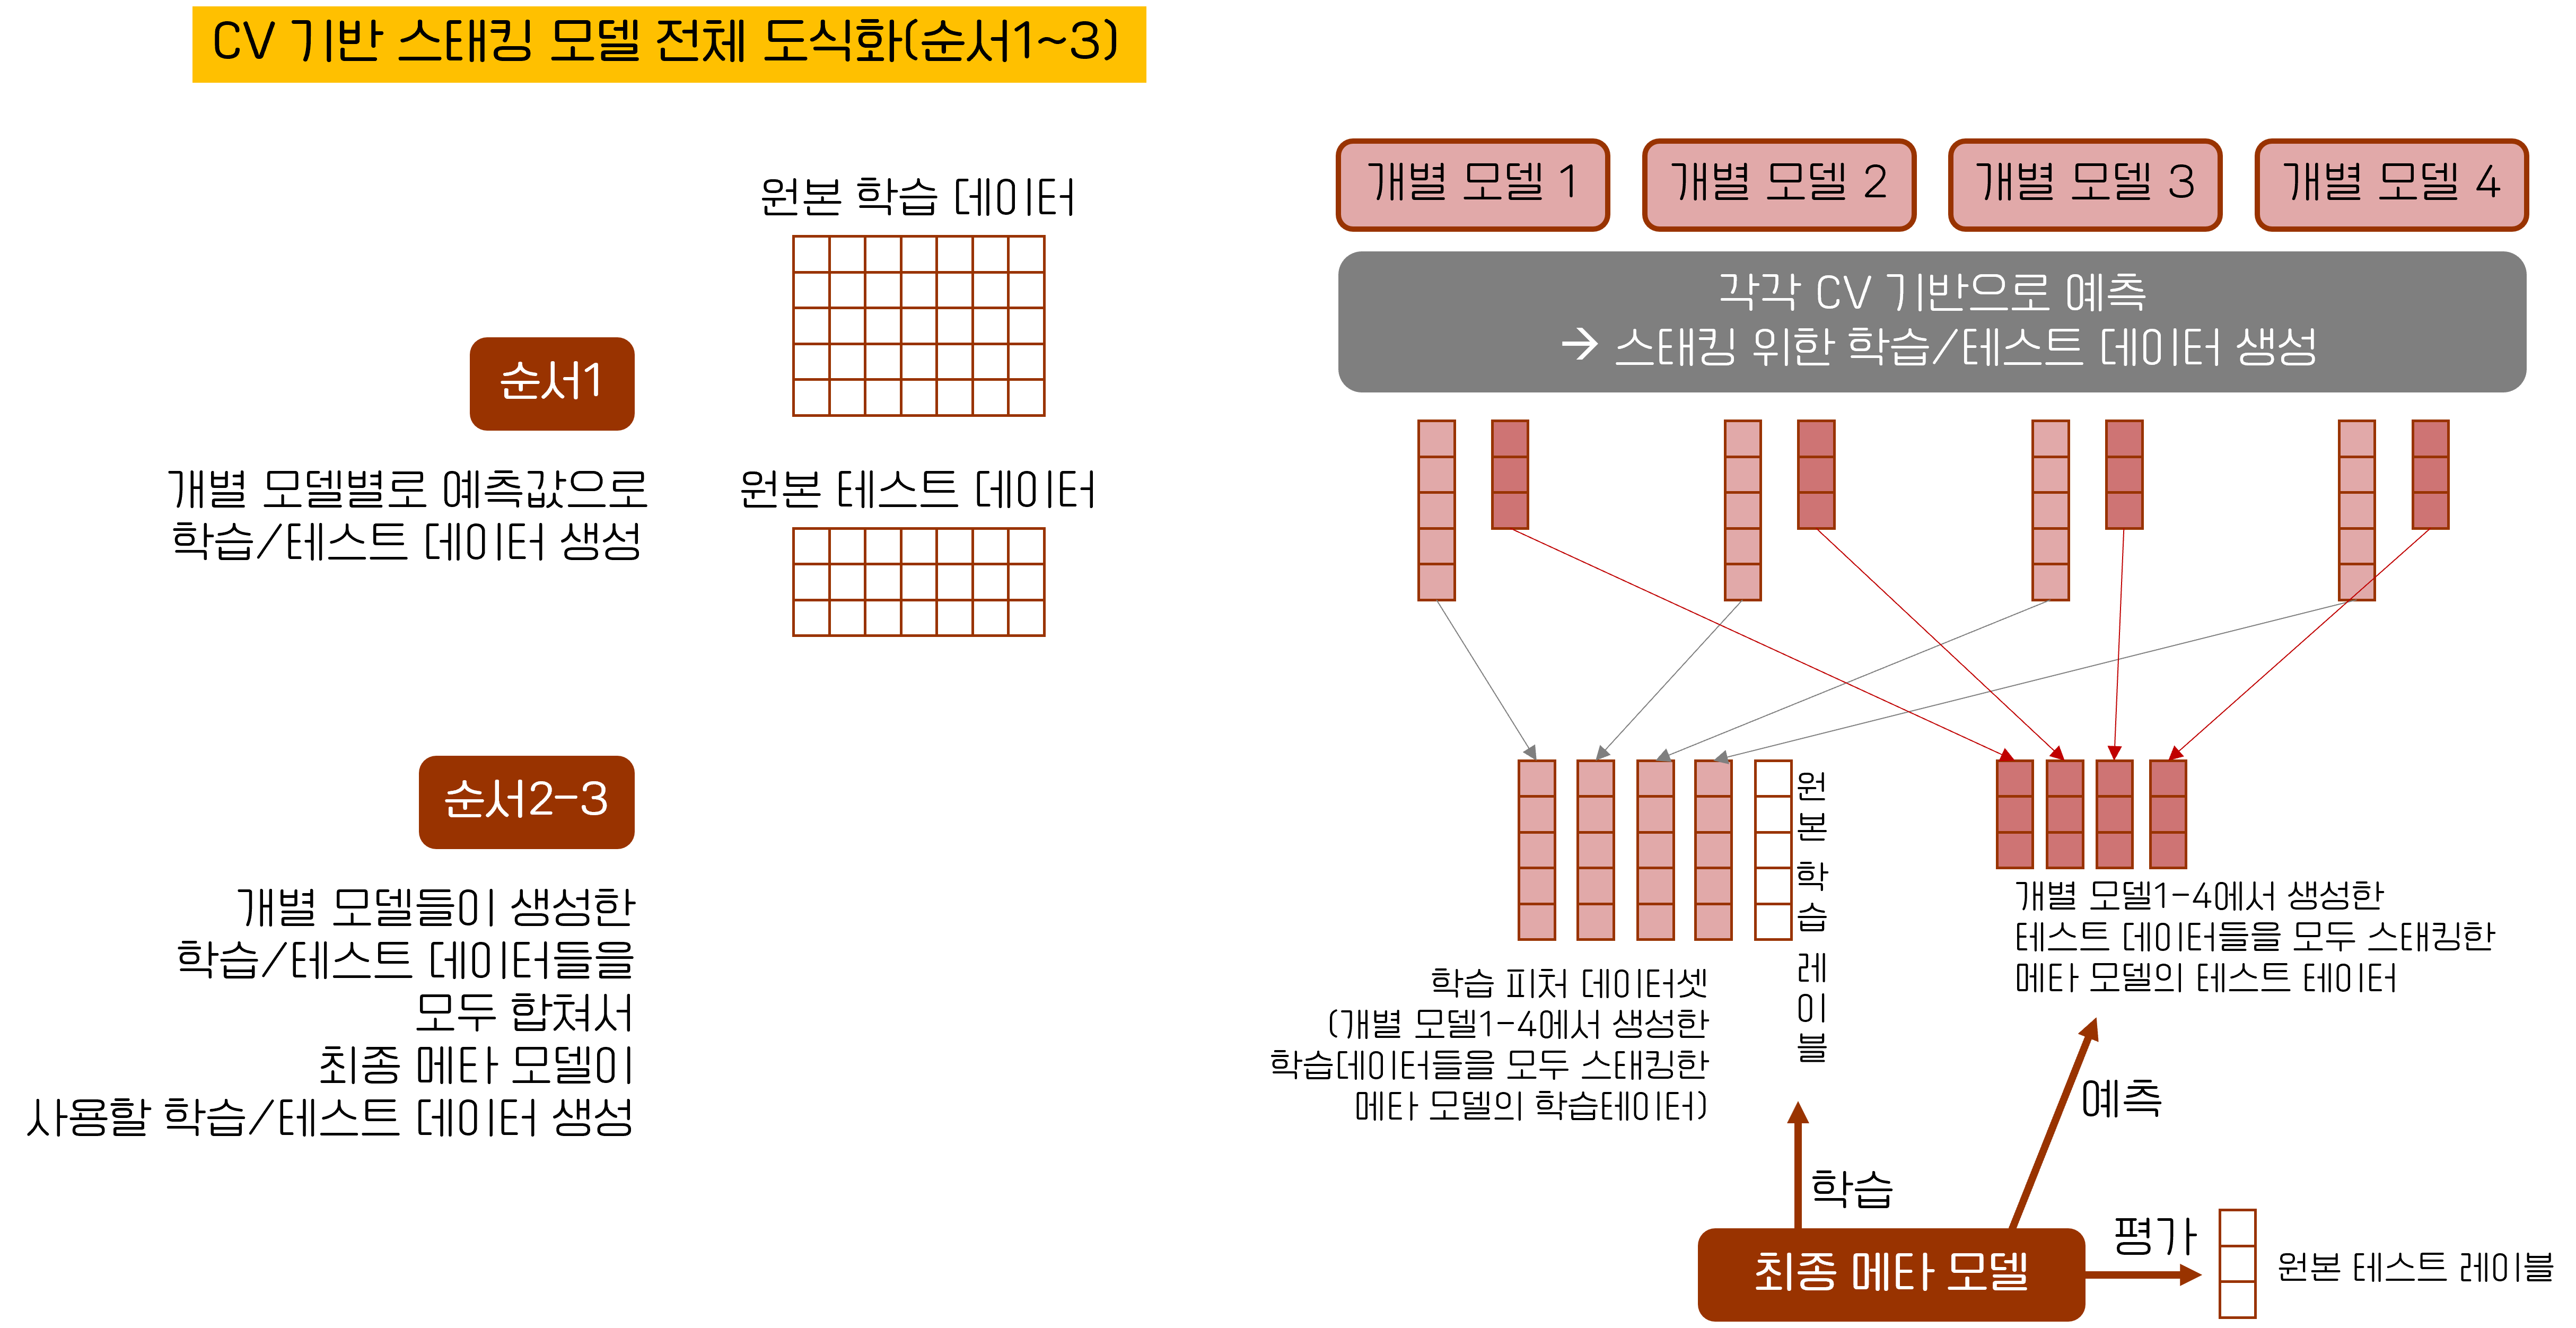

In [14]:
### 순서1부분

#개별 기반 모델에서 최종 메타보델이 사용할 학습/테스트 데이터 생성
def get_stacking_base_datasets(model, x_train_n, y_train_n, x_test_n, n_folds):
    kf = KFold(n_splits=n_folds, shuffle=False, random_state=0)
    train_fold_pred = np.zeros((x_train_n.shape[0], 1)) #메타 모델이 사용할 학습 데이터 반환 위한 넘파이 배열 초기화
    test_pred = np.zeros((x_test_n.shape[0], n_folds))
    print(model.__class__.__name__, ' model 시작 ')
    
    for folder_counter, (train_index, valid_index) in enumerate(kf.split(x_train_n)):
        print('\t폴드 세트 : ', folder_counter, ' 시작')
        x_tr = x_train_n[train_index]
        y_tr = y_train_n[train_index]
        x_te = x_train_n[valid_index]
        
        model.fit(x_tr, y_tr)
        train_fold_pred[valid_index, :] = model.predict(x_te).reshape(-1, 1)
        test_pred[:, folder_counter] = model.predict(x_test_n)
        
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1, 1)
    
    return train_fold_pred, test_pred_mean


#개별 모델 함수 수행
knn_train, knn_test = get_stacking_base_datasets(knn_clf, x_train, y_train, x_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, x_train, y_train, x_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, x_train, y_train, x_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, x_train, y_train, x_test, 7)

C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(
C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(


KNeighborsClassifier  model 시작 
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
	폴드 세트 :  5  시작
	폴드 세트 :  6  시작
RandomForestClassifier  model 시작 
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
	폴드 세트 :  5  시작
	폴드 세트 :  6  시작


C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(
C:\Users\lumos\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:293: FutureWarning: Setting a random_state has no effect since shuffle is False. This will raise an error in 0.24. You should leave random_state to its default (None), or set shuffle=True.
  warnings.warn(


DecisionTreeClassifier  model 시작 
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
	폴드 세트 :  5  시작
	폴드 세트 :  6  시작
AdaBoostClassifier  model 시작 
	폴드 세트 :  0  시작
	폴드 세트 :  1  시작
	폴드 세트 :  2  시작
	폴드 세트 :  3  시작
	폴드 세트 :  4  시작
	폴드 세트 :  5  시작
	폴드 세트 :  6  시작


In [17]:
### 순서 2

Stack_final_x_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_x_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 shape : ', x_train.shape, ' 원본 테스트 피처 shape : ', x_test.shape)
print('스태킹 학습 피처 데이터 shape : ', Stack_final_x_train.shape, ' 스태킹 테스트 피처 데이터 shape : ', Stack_final_x_test.shape)

원본 학습 피처 데이터 shape :  (455, 30)  원본 테스트 피처 shape :  (114, 30)
스태킹 학습 피처 데이터 shape :  (455, 4)  스태킹 테스트 피처 데이터 shape :  (114, 4)


In [18]:
### 순서 3

lr_final.fit(Stack_final_x_train, y_train)
stack_final = lr_final.predict(Stack_final_x_test)

print('최종 메타 모델의 예측 정확도 : {0:.4f}'.format(accuracy_score(y_test, stack_final)))

최종 메타 모델의 예측 정확도 : 0.9737


* 스태킹을 이루는 모델은 최적으로 파라미터를 튜닝한 뒤 모델을 만드는 것이 일반적
* 여러 명으로 이뤄진 분석 팀에서 개별적으로 각각 모델 최적 학습시켜 더 빠르게 최적화
* '스태킹 모델의 파라미터 튜닝' = '개별 알고리즘 모델의 파라미터를 최적으로 튜닝하기'